In [2]:
import itertools
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the possible collisions
def get_transitions(state):
    a, b, c = state
    transitions = []
    # A + B -> C + C
    if a > 0 and b > 0: transitions.append((a-1, b-1, c+2))
    # B + C -> A + A
    if b > 0 and c > 0: transitions.append((a+2, b-1, c-1))
    # A + C -> B + B
    if a > 0 and c > 0: transitions.append((a-1, b+2, c-1))
    return transitions

# 2. Define an equilibrium state
def is_equilibrium(state):
    a, b, c = state
    # Equilibrium if only one species exists (two counts are 0)
    return (a == 0 and b == 0) or (a == 0 and c == 0) or (b == 0 and c == 0)

# 3. Define the invariant Delta (modulo 3)
def calculate_delta(state):
    a, b, c = state
    return ((b - c) % 3, (a - c) % 3, (a - b) % 3)

# 4. Function to explore all reachable states from a starting configuration
def explore_system(start_state):
    visited = set()
    queue = [start_state]
    equilibria_reached = set()
    
    while queue:
        current = queue.pop(0)
        if current not in visited:
            visited.add(current)
            
            if is_equilibrium(current):
                equilibria_reached.add(current)
            else:
                for next_state in get_transitions(current):
                    if next_state not in visited:
                        queue.append(next_state)
                        
    # If no equilibria are reachable, it's trapped in a cycle (recurrent class)
    reaches_equilibrium = len(equilibria_reached) > 0
    return visited, equilibria_reached, reaches_equilibrium

In [3]:
print("--- Case n=2 ---")
start_2 = (1, 1, 0)
visited_2, eq_2, reaches_eq_2 = explore_system(start_2)
print(f"Start: {start_2} -> Reachable states: {visited_2}")
print(f"Equilibria reached: {eq_2}\n")

print("--- Case n=3 ---")
# The state that reaches equilibrium
start_3a = (1, 1, 1)
visited_3a, eq_3a, reaches_eq_3a = explore_system(start_3a)
print(f"Start: {start_3a} -> Equilibria reached: {eq_3a}")

# The state that cycles
start_3b = (2, 1, 0)
visited_3b, eq_3b, reaches_eq_3b = explore_system(start_3b)
print(f"Start: {start_3b} -> Reachable states: {visited_3b}")
print(f"Equilibria reached: {eq_3b} (Indicates a Cycle/Recurrent Class)")
print('\n')
print("--- Case n=4 (The branching tree) ---")
start_4 = (2, 2, 0)
visited_4, eq_4, reaches_eq_4 = explore_system(start_4)

print(f"All states visited from {start_4}:")
for state in visited_4:
    if is_equilibrium(state):
        print(f"  {state} <-- EQUILIBRIUM")
    else:
        print(f"  {state} -> Transitions to: {get_transitions(state)}")

print(f"\nFinal Equilibria reached from {start_4}: {eq_4}")
# This confirms your observation that everything in n=4 hits equilibrium.

--- Case n=2 ---
Start: (1, 1, 0) -> Reachable states: {(1, 1, 0), (0, 0, 2)}
Equilibria reached: {(0, 0, 2)}

--- Case n=3 ---
Start: (1, 1, 1) -> Equilibria reached: {(3, 0, 0), (0, 3, 0), (0, 0, 3)}
Start: (2, 1, 0) -> Reachable states: {(2, 1, 0), (0, 2, 1), (1, 0, 2)}
Equilibria reached: set() (Indicates a Cycle/Recurrent Class)


--- Case n=4 (The branching tree) ---
All states visited from (2, 2, 0):
  (0, 0, 4) <-- EQUILIBRIUM
  (0, 3, 1) -> Transitions to: [(2, 2, 0)]
  (1, 1, 2) -> Transitions to: [(0, 0, 4), (3, 0, 1), (0, 3, 1)]
  (3, 0, 1) -> Transitions to: [(2, 2, 0)]
  (2, 2, 0) -> Transitions to: [(1, 1, 2)]

Final Equilibria reached from (2, 2, 0): {(0, 0, 4)}


In [4]:
print("--- Testing the Invariant Delta ---")
large_state = (85, 3, 12)
n_large = sum(large_state)

print(f"Initial State: {large_state}, Total n: {n_large}")
print(f"n modulo 3: {n_large % 3}")

# Calculate invariant for the start state
delta_initial = calculate_delta(large_state)
print(f"Delta for (85, 3, 12): {delta_initial}")

# Calculate invariant for the predicted equilibrium (100, 0, 0)
predicted_eq = (n_large, 0, 0)
delta_eq = calculate_delta(predicted_eq)
print(f"Delta for {predicted_eq}: {delta_eq}")

if delta_initial == delta_eq:
    print("Match confirmed! The system will uniquely evolve to (100, 0, 0).")

--- Testing the Invariant Delta ---
Initial State: (85, 3, 12), Total n: 100
n modulo 3: 1
Delta for (85, 3, 12): (0, 1, 1)
Delta for (100, 0, 0): (0, 1, 1)
Match confirmed! The system will uniquely evolve to (100, 0, 0).


In [5]:
print("--- Global Structure: Does it reach equilibrium? ---")
print(f"{'n':<4} | {'n % 3':<5} | {'Total States':<13} | {'All Reach Eq?':<15}")
print("-" * 45)

for n in range(1, 11):
    # Generate all valid (a,b,c) combinations where a+b+c = n
    all_states = [(a, b, n - a - b) for a in range(n + 1) for b in range(n - a + 1)]
    
    all_reach_equilibrium = True
    
    for state in all_states:
        _, equilibria, reaches_eq = explore_system(state)
        if not reaches_eq:
            all_reach_equilibrium = False
            break # We found a cycle, no need to check the rest for this n
            
    print(f"{n:<4} | {n % 3:<5} | {len(all_states):<13} | {str(all_reach_equilibrium):<15}")

--- Global Structure: Does it reach equilibrium? ---
n    | n % 3 | Total States  | All Reach Eq?  
---------------------------------------------
1    | 1     | 3             | True           
2    | 2     | 6             | True           
3    | 0     | 10            | False          
4    | 1     | 15            | True           
5    | 2     | 21            | True           
6    | 0     | 28            | False          
7    | 1     | 36            | True           
8    | 2     | 45            | True           
9    | 0     | 55            | False          
10   | 1     | 66            | True           


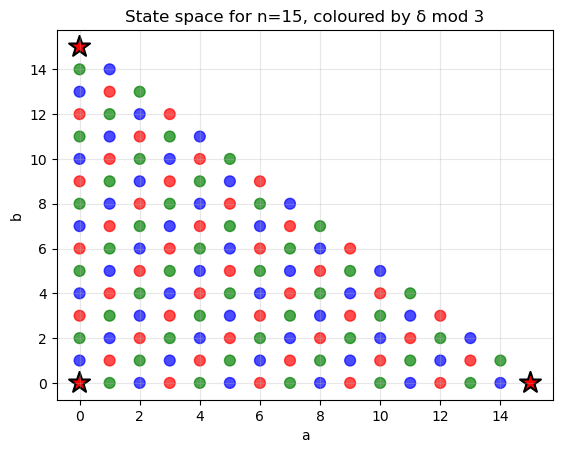

In [16]:
import matplotlib.pyplot as plt

def delta_mod3(a, b, c):
    return ((b-c) % 3, (a-c) % 3, (a-b) % 3)

def is_equilibrium(a, b, c):
    return (a == 0 and b == 0) or (a == 0 and c == 0) or (b == 0 and c == 0)

def plot_state_space(n):
    xs, ys, colors = [], [], []
    eq_x, eq_y, eq_colors = [], [], []

    color_map = {}
    color_list = ['red', 'blue', 'green', 'purple', 'orange', 'black']

    for a in range(n+1):
        for b in range(n+1-a):
            c = n - a - b
            d = delta_mod3(a, b, c)

            if d not in color_map:
                color_map[d] = color_list[len(color_map) % len(color_list)]

            col = color_map[d]

            if is_equilibrium(a, b, c):
                eq_x.append(a)
                eq_y.append(b)
                eq_colors.append(col)
            else:
                xs.append(a)
                ys.append(b)
                colors.append(col)

    plt.figure()

    # Normal states
    plt.scatter(xs, ys, c=colors, s=60, alpha=0.7)

    # Equilibrium states (same colour, different shape)
    plt.scatter(eq_x, eq_y, c=eq_colors, s=250, marker='*', edgecolors='black', linewidths=1.5)

    plt.xlabel("a")
    plt.ylabel("b")
    plt.title(f"State space for n={n}, coloured by δ mod 3")

    plt.grid(alpha=0.3)
    plt.show()


# RUN
plot_state_space(15)